# Tokopedia ETL Pipeline - Exploratory Data Analysis (EDA)

## Project Overview

Project ini merupakan implementasi sederhana dari ETL (Extract, Transform, Load) Pipeline menggunakan Python.

Tahapan ETL yang dilakukan:

- Extract data produk Tokopedia menggunakan Selenium & BeautifulSoup
- Transform data (Cleaning & Feature Engineering).
- Validate hasil transformasi.
- Load data ke CSV dan SQLite.

Notebook ini digunakan untuk melakukan Exploratory Data Analysis (EDA) terhadap data hasil ETL.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [21]:
df = pd.read_csv("../data/processed/Data_Seblak_Clean.csv")

df.head()

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,55000,Rasa Juara Indonesia,Kab. Bandung,50,5.0,2750000,Mahal,No
1,Buku Anak Komik Next G Seblak Level Pedas,28160,Mizanstore.id,Kab. Sidoarjo,15,5.0,422400,Mahal,No
2,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Kab. Sidoarjo,50,4.9,1716000,Mahal,No
3,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No
4,SUBRON Panci Masak Paket 8IN1 14CM 17CM 6pcs S...,59900,SUBRON KITCHENWARE,Kab. Bandung,29,4.7,1737100,Mahal,No


## Dataset Information

In [22]:
df.shape

(26, 9)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     26 non-null     object 
 1   Price            26 non-null     int64  
 2   Seller           26 non-null     object 
 3   City             26 non-null     object 
 4   Sold             26 non-null     int64  
 5   Rating           26 non-null     float64
 6   Revenue          26 non-null     int64  
 7   Price_Category   22 non-null     object 
 8   Popular_Product  26 non-null     object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.0+ KB


In [24]:
df.describe(include="all")

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
count,26,26.000000,26,26,26.000000,26.000000,2.600000e+01,22,26
unique,26,NaN,11,10,NaN,NaN,NaN,3,2
top,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,NaN,Kylafood,Kab. Bandung,NaN,NaN,NaN,Mahal,No
freq,1,NaN,7,7,NaN,NaN,NaN,19,18
mean,NaN,39939.884615,NaN,NaN,107.461538,4.550000,6.299090e+06,NaN,NaN
std,NaN,30324.348925,NaN,NaN,158.495989,0.959687,1.437982e+07,NaN,NaN
min,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000e+00,NaN,NaN
25%,NaN,23225.000000,NaN,NaN,12.000000,4.700000,8.462350e+04,NaN,NaN
50%,NaN,35910.000000,NaN,NaN,55.000000,4.800000,1.180800e+06,NaN,NaN
75%,NaN,56875.000000,NaN,NaN,100.000000,4.800000,4.097500e+06,NaN,NaN


## Missing Value

In [25]:
df.isnull().sum()

Product Name       0
Price              0
Seller             0
City               0
Sold               0
Rating             0
Revenue            0
Price_Category     4
Popular_Product    0
dtype: int64

## Duplicate Data

In [26]:
df.duplicated().sum()

np.int64(0)

## Top 10 Most Expensive Products

In [27]:
df.sort_values("Price", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
14,Kylafood Seblak Rempah Autentik isi (10pcs),125000,Kylafood,Bandung,250,4.8,31250000,Mahal,Yes
19,Kylafood Paket Seblak Cup intant isi 6 PCS Ins...,90000,Kylafood,Bandung,750,4.8,67500000,Mahal,Yes
20,"Kylafood Paket Combo Hemat (2 Seblak Rempah, 2...",84000,Kylafood,Bandung,250,4.8,21000000,Mahal,Yes
11,1KG KERUPUK SEBLAK JENGKOL PEDAS,60000,CEMILANKU KAYA BUMBU,Kab.Ciamis,80,4.8,4800000,Mahal,No
4,SUBRON Panci Masak Paket 8IN1 14CM 17CM 6pcs S...,59900,SUBRON KITCHENWARE,Kab. Bandung,29,4.7,1737100,Mahal,No
16,Kylafood Paket 2 Seblak Cup + 2 Basreng pedas,59000,Kylafood,Bandung,70,4.8,4130000,Mahal,No
24,"Kylafood Paket (Seblak Cup, Seblak Rempah, Bas...",57500,Kylafood,Bandung,40,4.7,2300000,Mahal,No
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,55000,Rasa Juara Indonesia,Kab. Bandung,50,5.0,2750000,Mahal,No
17,1KG SEBLAK CAMPUR DAUN JERUK,50000,CEMILANKU KAYA BUMBU,Kab.Ciamis,70,4.8,3500000,Mahal,No
23,1KG SEBLAK KERUPUK BETON DAUN JERUK / KERUPUK ...,50000,CEMILANKU KAYA BUMBU,Kab.Ciamis,1,4.7,50000,Mahal,No


## Top Seller

In [28]:
df["Seller"].value_counts().head(10)

Seller
Kylafood                       7
CEMILANKU KAYA BUMBU           4
Rasa Juara Indonesia           4
SUBRON KITCHENWARE             3
Mizanstore.id                  2
Pisang Goreng Madu Bu Nanik    1
Cap Ibu Shop                   1
No Seller                      1
Mama Fuji Real                 1
Hypermart Cirebon              1
Name: count, dtype: int64

## Top City

In [29]:
df["City"].value_counts().head(10)

City
Kab. Bandung        7
Bandung             7
Kab.Ciamis          4
Kab. Sidoarjo       2
Jakarta Barat       1
Jakarta Timur       1
Unknown City        1
Tangerang           1
Cirebon             1
Kab. Tasikmalaya    1
Name: count, dtype: int64

## Highest Rated Products

In [30]:
df.sort_values("Rating", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
0,[HARGA SPESIAL] Paket BM 3: 1 Seblak + 1 Cuank...,55000,Rasa Juara Indonesia,Kab. Bandung,50,5.0,2750000,Mahal,No
1,Buku Anak Komik Next G Seblak Level Pedas,28160,Mizanstore.id,Kab. Sidoarjo,15,5.0,422400,Mahal,No
8,CAP IBU Bumbu Seblak Bandung - Bumbu Masak Ins...,0,Cap Ibu Shop,Jakarta Timur,250,5.0,0,NaN,Yes
9,Seblak Kuah Instan Ibro Bandung,28599,Pisang Goreng Madu Bu Nanik,Jakarta Barat,250,5.0,7149750,Mahal,Yes
2,Buku Komik Next G vol. 664: Tragedi Seblak | M...,34320,Mizanstore.id,Kab. Sidoarjo,50,4.9,1716000,Mahal,No
3,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No
14,Kylafood Seblak Rempah Autentik isi (10pcs),125000,Kylafood,Bandung,250,4.8,31250000,Mahal,Yes
13,500GR SEBLAK KRUPUK RAFAEL VIRAL,40000,CEMILANKU KAYA BUMBU,Kab.Ciamis,100,4.8,4000000,Mahal,Yes
12,Seblak Juara - Seblak Instan Asli Bandung | Ot...,22000,Rasa Juara Indonesia,Kab. Bandung,2,4.8,44000,Sedang,No
11,1KG KERUPUK SEBLAK JENGKOL PEDAS,60000,CEMILANKU KAYA BUMBU,Kab.Ciamis,80,4.8,4800000,Mahal,No


## Distribution of Product Price

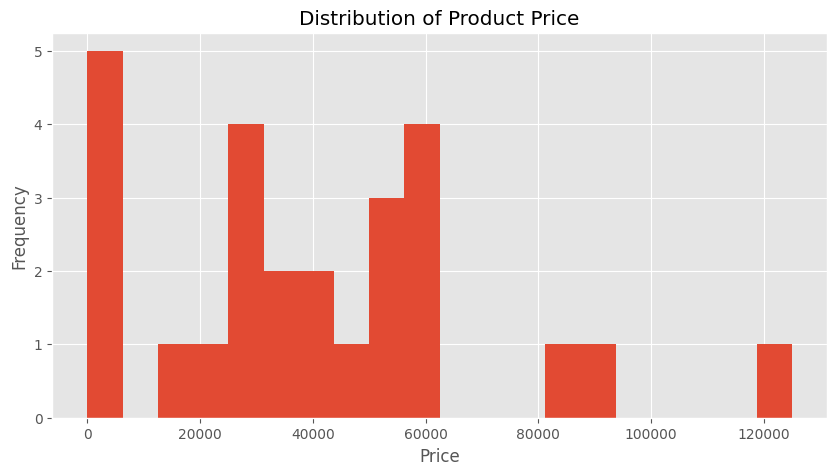

In [31]:
plt.figure(figsize=(10,5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Product Price")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

## Distribution of Rating

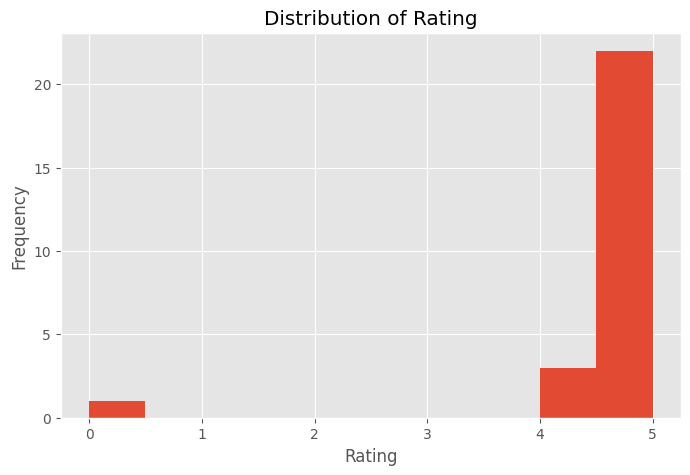

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Distribution of Rating")

plt.xlabel("Rating")

plt.ylabel("Frequency")

plt.show()

## Top 10 Most Sold Products

In [33]:
df.sort_values("Sold", ascending=False).head(10)

,Product Name,Price,Seller,City,Sold,Rating,Revenue,Price_Category,Popular_Product
19,Kylafood Paket Seblak Cup intant isi 6 PCS Ins...,90000,Kylafood,Bandung,750,4.8,67500000,Mahal,Yes
9,Seblak Kuah Instan Ibro Bandung,28599,Pisang Goreng Madu Bu Nanik,Jakarta Barat,250,5.0,7149750,Mahal,Yes
6,SUBRON Panci Ramyun Stainless 14CM 17CM Esteti...,37500,SUBRON KITCHENWARE,Kab. Bandung,250,4.1,9375000,Mahal,Yes
20,"Kylafood Paket Combo Hemat (2 Seblak Rempah, 2...",84000,Kylafood,Bandung,250,4.8,21000000,Mahal,Yes
14,Kylafood Seblak Rempah Autentik isi (10pcs),125000,Kylafood,Bandung,250,4.8,31250000,Mahal,Yes
8,CAP IBU Bumbu Seblak Bandung - Bumbu Masak Ins...,0,Cap Ibu Shop,Jakarta Timur,250,5.0,0,NaN,Yes
13,500GR SEBLAK KRUPUK RAFAEL VIRAL,40000,CEMILANKU KAYA BUMBU,Kab.Ciamis,100,4.8,4000000,Mahal,Yes
18,INDOMIE MI INSTANT RASA SEBLAK HOT JELET,3410,Hypermart Cirebon,Cirebon,100,4.8,341000,Murah,Yes
11,1KG KERUPUK SEBLAK JENGKOL PEDAS,60000,CEMILANKU KAYA BUMBU,Kab.Ciamis,80,4.8,4800000,Mahal,No
3,[HARGA SPESIAL] Paket BM 1: 2 Seblak + 1 Cuank...,0,Rasa Juara Indonesia,Kab. Bandung,70,4.8,0,NaN,No


## Insight

### Summary

- Dataset berhasil diambil menggunakan Selenium dan BeautifulSoup.
- Data telah dibersihkan melalui proses ETL Pipeline.
- Missing value telah ditangani pada tahap Transform.
- Duplicate data telah dihapus.
- Dataset disimpan dalam format CSV dan SQLite.
- Mayoritas produk memiliki harga pada rentang harga menengah.
- Sebagian besar produk memiliki rating tinggi (>4.5).
- Beberapa seller mendominasi jumlah produk pada hasil scraping.